Plotting DiazoDB Comparison Results

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

Bar chart

In [ ]:
category_names = ['I', 'II', 'III', 'III-anf', 'III-vnf', 'IVa']

results = {'DiazoDB\n7911': np.array([2064, 4178, 338, 271, 216, 168]), 
            'NFix\n4488': np.array([4085, 0, 0, 261, 56, 0]),
            'NSDB\n1536': np.array([139, 181, 31, 17, 17, 0]), 
            'Cyano\n1342': np.array([1310, 9, 0, 23, 0, 0])}


labels = list(results.keys())
data = np.array(list(results.values()))
data_cum = data.cumsum(axis=1)
category_colors = plt.colormaps['RdYlGn'](
    np.linspace(0.15, 0.85, data.shape[1]))[::-1]

fig, ax = plt.subplots(figsize=(9.2, 3))
ax.invert_yaxis()
ax.xaxis.set_visible(False)
ax.set_xlim(0, np.sum(data, axis=1).max())

for i, (colname, color) in enumerate(zip(category_names, category_colors)):
    widths = data[:, i]
    starts = data_cum[:, i] - widths
    # reduce spacing between bars
    rects = ax.barh(labels, widths, left=starts, height=0.7,
                    label=colname, color=color)

    r, g, b, _ = color
    text_color = 'white' if r * g * b < 0.5 else 'darkgrey'
    # ax.bar_label(rects, label_type='center', color=text_color)
ax.legend(ncols=len(category_names), bbox_to_anchor=(0, 1),
            loc='lower left', fontsize='small')

fig.savefig('../diazoDB-comparison/diazoDB-comp-counts.svg', format='svg',
            dpi=6000, transparent=True)
plt.show()

F1??? v. DB size

In [ ]:
input = pd.read_csv('f1_counts.csv')
input['F1'] = input['TP'] / (input['TP'] + 0.5 * (input['FP'] + input['FN']))

venn diagram

In [ ]:
cutoff = 0.8
file = f"clusterDB_{cutoff}/nifD_allDB_clustered_cluster.tsv"
clusters = pd.read_csv(file, sep='\t', header=None, names=['cluster','gene'])
clusters.set_index('cluster', inplace=True)

total_unique = clusters.index.nunique()
databases = ('NFixPlanet', 'NFixDB', 'NSDB', '..', 'Nif_finder')
counts = {db:[] for db in databases} # [unique, sharedDB1, sharedDB2, ...]

# for each database, calculate the number of unique clusters
for i, db in enumerate(databases):
    db_unique = clusters[clusters.index.str.contains(db)]
    other_db = databases[:i] + databases[i+1:]
    contains_otherDB = db_unique.groupby(level=0)['gene'].transform(
        lambda genes: genes.str.startswith(other_db, na=False).any())
    unique_count = db_unique[~contains_otherDB].index.nunique()
    counts[db] = unique_count
    print(f"{db}: {unique_count} unique clusters")




NFixPlanet: 108 unique clusters
NFixDB: 226 unique clusters
NSDB: 7 unique clusters
..: 458 unique clusters
Nif_finder: 1 unique clusters


UpSet plot

/resnick/groups/enviromics/zahra/miniconda3/envs/parse_hmm/lib/python3.12/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/resnick/groups/enviromics/zahra/miniconda3/envs/parse_hmm/lib/python3.12/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work becaus

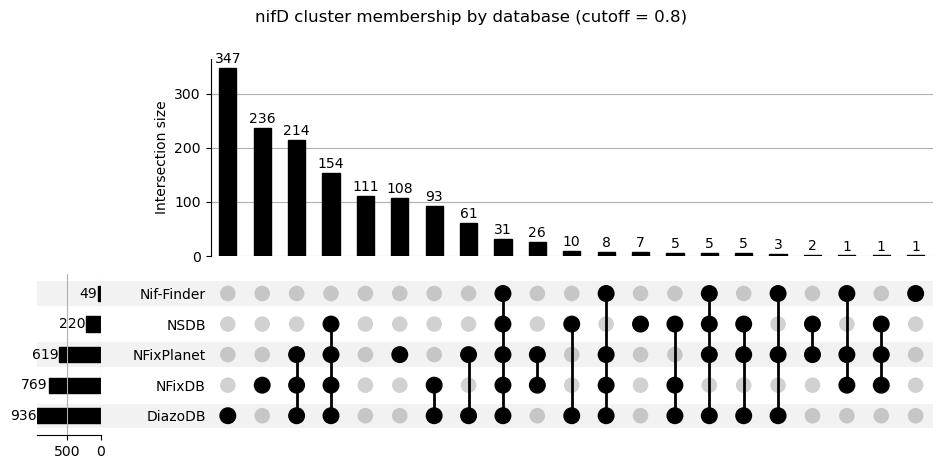

In [15]:
from upsetplot import UpSet, from_indicators

database_prefixes = {
    'NFixPlanet': ('NFixPlanet',),
    'NFixDB': ('NFixDB',),
    'NSDB': ('NSDB',),
    'DiazoDB': ('..',),
    'Nif-Finder': ('Nif_finder',),
}

cluster_membership = pd.DataFrame({
    database: clusters.groupby(level=0)['gene'].apply(
        lambda genes: genes.str.startswith(prefixes, na=False).any()
    )
    for database, prefixes in database_prefixes.items()
})

upset_data = from_indicators(cluster_membership.columns, data=cluster_membership)

fig = plt.figure(figsize=(11, 7))
UpSet(upset_data, subset_size='count', show_counts=True, sort_by='cardinality').plot(fig=fig)

upset = UpSet(
    upset_data,
    subset_size='count',
    show_counts=True,
    sort_by='cardinality',
    facecolor='#2c7fb8',
    other_dots_color='#bdbdbd',
    shading_color='#eeeeee',
)

upset.style_subsets(
    present=['NFixDB'],
    facecolor='#e34a33',
    label='NFixDB intersections',
)

fig.suptitle(f'nifD cluster membership by database (cutoff = {cutoff})')
fig.savefig(f'upset_nifD_{cutoff}.svg', format='svg', dpi=6000, transparent=True)
plt.show()


anfO analysis

In [ ]:
results = pd.read_csv("../results/final/nif_clusters.csv")

anfO = results[results['Nitrogenase Set'].str.contains('O', na=False)] # arose independent of alt metals?
anfG = results[results['Nitrogenase Set'].str.contains('G', na=False)] # orphan protein?

print(anfO[anfO['Group']=='Group 2'])

                 GenomeID                contig  operon cluster  \
48     GB_GCA_000802095.1        JUEB01000015.1       1     nif   
66     GB_GCA_000961575.1        LADP01000032.1       1     nif   
67     GB_GCA_000961585.1        LADN01000053.1       1     nif   
68     GB_GCA_000961595.1        LADO01000055.1       1     nif   
99     GB_GCA_001516055.1        LOEZ01000019.1       1     nif   
...                   ...                   ...     ...     ...   
12427  RS_GCF_902477725.1  NZ_CABSIF010000016.1       1     nif   
12428  RS_GCF_902702915.1         NZ_LR738849.1       3     nif   
12517  RS_GCF_963664155.2  NZ_CAXXXH010000001.1       1     nif   
12543  RS_GCF_963668665.2  NZ_CAXXLU010000002.1       6     nif   
12580  RS_GCF_963678795.2  NZ_CAXXIR010000001.1       1     nif   

           Nitrogenase Set  Location_start  Location_end  Orientation  \
48     H, D, K, E, N, B, O           18509         27828            1   
66     H, D, K, E, N, B, O           42734       